# Feature-Level Fusion (Approach a): Degree-Conditioned Gating

**Goal**: replace the raw R-GCN node embedding with a degree-conditioned mix of graph + text:

$$
h_{\text{fused}}(v) = \alpha(v) \cdot h_{\text{graph}}(v) + (1 - \alpha(v)) \cdot h_{\text{LLM}}(v),\quad
\alpha(v) = \sigma(w \cdot \log(\deg(v) + 1) + b)
$$

**Two phases**:
1. **Phase 1 — Analytical gate calibration (no gradients).** Pair-level quartile partition by KG-structural drug log-degree → fixed-alpha sweep per quartile → closed-form linear regression on `(median_log_deg, logit(alpha*))`. The R-GCN forward pass runs **once**; `h_graph` is reused across all 4 quartiles × 11 alphas. Gate is frozen immediately after fitting.
2. **Phase 2 — Supervised fine-tuning (gate frozen).** Standard ranking loss + mask-restricted anchoring loss over rows with cached text only.

Run the experiment cell **twice** — once with `desc_tier="gpt4o"`, once with `desc_tier="hybrid"` — keeping both result dicts in memory for the comparison cell at the end.

## 0. Setup

In [1]:
!pip install -q torch torch-geometric wandb transformers pyyaml matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 53.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'
PROJECT_ROOT = '/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702'
sys.path.insert(0, PROJECT_ROOT)
%cd {PROJECT_ROOT}


Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/16u6rgAZFbJh8HQhxtjFa2_tq8qbi6dht/BMI702


In [3]:
import wandb
WANDB_API_KEY = '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'
key = WANDB_API_KEY.strip()
wandb.login(key=key, relogin=True)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: beatrice-chen (bmi702) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
import json
import logging
import numpy as np
import pandas as pd
import torch

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(name)s: %(message)s')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 1. Config

Edit `desc_tier` between runs to switch between `"gpt4o"` and `"hybrid"`. All other knobs stay fixed.

In [18]:
from pathlib import Path

config = {
    # Data
    'data_dir': 'data/primekg',
    'split_dir': 'data/splits',
    'checkpoint_path': 'data/weights/rgcn_best_model.pt',
    'results_dir': 'results/tables',

    # Text source
    'encoder_name': 'biolinkbert',
    'desc_tier': 'gpt4o',          # change to 'hybrid' for the second run
    'projection': 'nonlinear_ae',
    'embed_dir': 'data/embeddings_256',

    # Dimensions
    'embed_dim': 256,              # locked from checkpoint inspection

    # Memory / smoke-test controls
    'use_amp': True,               # mixed precision on T4
    'skip_phase1': False,          # set True to jump straight into Phase 2
    'phase1_override_w': 0.0,     # alpha=0.5 when skip_phase1=True
    'phase1_override_b': 0.0,

    # Phase 1 — analytical gate calibration
    'alpha_sweep_grid': [i / 10 for i in range(11)],
    'n_quartiles': 4,

    # Phase 2 — supervised fine-tune
    'finetune_epochs': 100,
    'patience': 15,
    'anchoring_loss_weight': 0.1,
    'lr': 1e-3,
    'weight_decay': 1e-5,
    'margin': 1.0,
    'neg_ratio': 1,
    'accum_steps': 4,
    'grad_clip': 1.0,
    'batch_size': 512,
    'val_frac': 0.1,

    'seed': 42,
    'device': 'cuda',
}

# Tier coverage check (verification step 11 in plan)
for tier in ('gpt4o', 'hybrid'):
    base = Path(config['embed_dir']) / config['encoder_name'] / tier / config['projection']
    for fname in ('drug_embeddings.pt', 'phenotype_embeddings.pt'):
        p = base / fname
        assert p.exists(), f'Missing {p} — re-run scripts/cache_embeddings.py for tier={tier}'
    print(f'✓ tier={tier}: embeddings present at {base}')

# Checkpoint exists
assert Path(config['checkpoint_path']).exists(), (
    f'Missing baseline checkpoint at {config["checkpoint_path"]} — train it first or copy from Drive'
)


✓ tier=gpt4o: embeddings present at data/embeddings_256/biolinkbert/gpt4o/nonlinear_ae
✓ tier=hybrid: embeddings present at data/embeddings_256/biolinkbert/hybrid/nonlinear_ae


## 2. Run experiment — Tier: GPT-4o

In [9]:
## for testing only
config['use_amp'] = True
config['skip_phase1'] = True
config['phase1_override_w'] = 0.0
config['phase1_override_b'] = 0.0
config['finetune_epochs'] = 2
config['patience'] = 2

In [19]:
from src.models.feature_fusion_train import run_degree_cond_experiment

config['desc_tier'] = 'gpt4o'
results_gpt4o = run_degree_cond_experiment(config)
print('Phase 1 (gpt4o):', results_gpt4o['phase1'])
print('Test (indication-only) MRR :', results_gpt4o['test_metrics_ind']['MRR'])
print('Test (off-label-aug GT) MRR:', results_gpt4o['test_metrics_off']['MRR'])

/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702/src/data/primekg_loader.py:45: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  kg = pd.read_csv(data_dir / "kg.csv")


Train subset: 388 diseases, 4932 pairs
Val subset: 43 diseases
RGCN model loaded from checkpoint
Loading LLM-derived embeddings for h_llm_full construction...
computing log_degree for degree-conditioned fusion...
== Data and model setup complete ==
Phase 1: Sweeping alpha to calibrate gate parameters (w, b) for degree-conditioned fusion...
Phase 1 calibration: start with 388 diseases, alpha_grid=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], n_quartiles=4
Phase 1: built supervision pool |P|=2466 from 388 diseases (elapsed 0.0s)
Phase 1: quartile sizes = [615, 618, 610, 623], m_q = [6.665683746337891, 8.180600643157959, 8.607582092285156, 8.864604949951172] (elapsed 0.0s)
Phase 1: cached single h_graph encode (elapsed 0.5s)
Phase 1: quartile 1/4 start (|pairs|=615, |diseases|=225, m_q=6.6657, elapsed 0.5s)
Phase 1: quartile 1/4, alpha=0.00 start
Phase 1: quartile 1/4, alpha=0.00 done in 79.6s (pair_mrr=0.0008)
Phase 1: quartile 1/4, alpha=0.10 start
Phase 1: quartile 1/4, alph

Phase 1 calibration: finished in 3059.9s (w=1.2260, b=-6.8681, encode_calls=1)


/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702/src/models/feature_fusion_train.py:782: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


epoch,▁▁▂▂▃▃▄▄▅▅▆▆▇▇██
train/loss,█▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁
val/MRR,█▅▅▃▃▂▂▂▃▃▂▃▂▂▂▁
val/R@10,█▄▃▂▃▂▃▂▁▂▂▂▂▂▂▁
best_val_mrr,0.35898
epoch,15
phase1/b_fit,-6.86809
phase1/n_encode_calls,1
phase1/n_violations,1
phase1/q0_alpha_star,0.9
phase1/q0_m,6.66568


Phase 1 (gpt4o): {'m_q': [6.665683746337891, 8.180600643157959, 8.607582092285156, 8.864604949951172], 'optimal_alphas': [0.9, 0.7, 0.9, 1.0], 'w_fit': 1.2259510910436717, 'b_fit': -6.8680908797218985, 'n_encode_calls': 1, 'n_violations': 1}
Test (indication-only) MRR : 0.08766846236430927
Test (off-label-aug GT) MRR: 0.11169533020164675


## 3. Run experiment — Tier: Hybrid

In [ ]:
config['desc_tier'] = 'hybrid'
results_hybrid = run_degree_cond_experiment(config)
print('Phase 1 (hybrid):', results_hybrid['phase1'])
print('Test (indication-only) MRR :', results_hybrid['test_metrics_ind']['MRR'])
print('Test (off-label-aug GT) MRR:', results_hybrid['test_metrics_off']['MRR'])

/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702/src/data/primekg_loader.py:45: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  kg = pd.read_csv(data_dir / "kg.csv")


Train subset: 388 diseases, 4932 pairs
Val subset: 43 diseases
RGCN model loaded from checkpoint
Loading LLM-derived embeddings for h_llm_full construction...
computing log_degree for degree-conditioned fusion...
== Data and model setup complete ==
Phase 1: Sweeping alpha to calibrate gate parameters (w, b) for degree-conditioned fusion...
Phase 1 calibration: start with 388 diseases, alpha_grid=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], n_quartiles=4
Phase 1: built supervision pool |P|=2466 from 388 diseases (elapsed 0.0s)
Phase 1: quartile sizes = [615, 618, 610, 623], m_q = [6.665683746337891, 8.180600643157959, 8.607582092285156, 8.864604949951172] (elapsed 0.0s)
Phase 1: cached single h_graph encode (elapsed 0.5s)
Phase 1: quartile 1/4 start (|pairs|=615, |diseases|=225, m_q=6.6657, elapsed 0.5s)
Phase 1: quartile 1/4, alpha=0.00 start
Phase 1: quartile 1/4, alpha=0.00 done in 79.4s (pair_mrr=0.0013)
Phase 1: quartile 1/4, alpha=0.10 start
Phase 1: quartile 1/4, alph

## 4. Gate-behavior visualization

Two layers in a single figure per tier:
- **Theoretical curve**: sweep `log_deg` linearly through `sigmoid(w · log_deg + b)` using the trained `(w, b)`.
- **Empirical scatter**: every drug node `v` plotted at `(log_degree[v], alpha(v))`.
- **Quartile anchors**: the 4 `(m_q, alpha*_q)` pairs from Phase 1 overlaid in a contrasting marker.

Saves to `results/figures/gate_behavior_{tier}.png`.

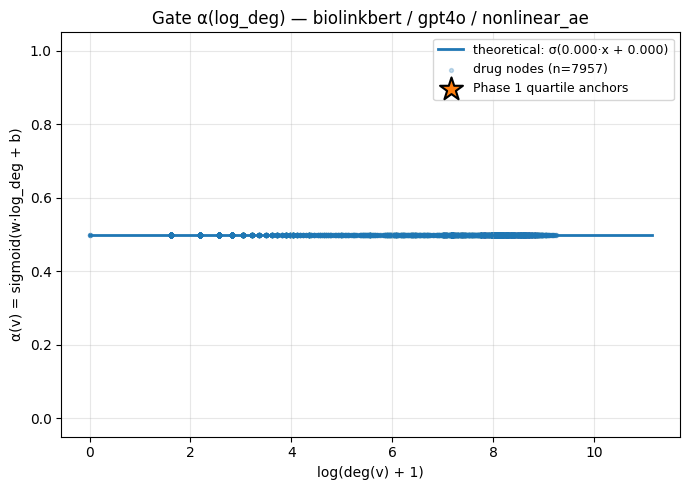

Saved results/figures/gate_behavior_gpt4o.png


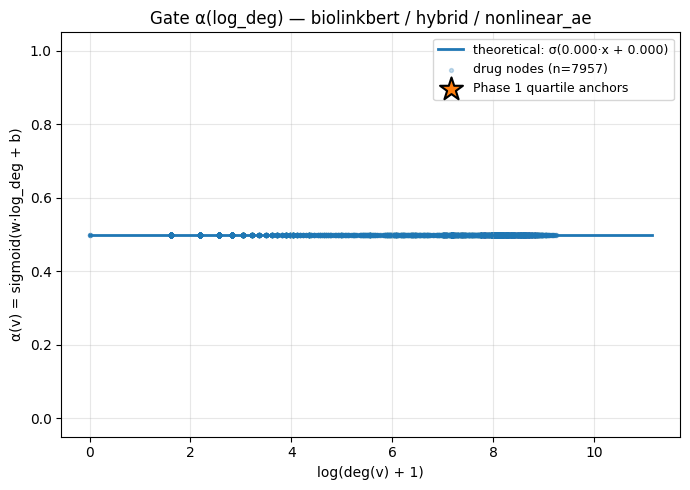

Saved results/figures/gate_behavior_hybrid.png


In [14]:
import math
import matplotlib.pyplot as plt
import numpy as np
import torch
from pathlib import Path

FIGURES_DIR = Path('results/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def plot_gate_behavior(results, tier_name, fig_path):
    log_degree = results['log_degree'].numpy()
    drug_indices = results['drug_indices_arr']
    w = results['fusion_w']
    b = results['fusion_b']
    m_q = results['phase1']['m_q']
    alpha_star = results['phase1']['optimal_alphas']

    sigmoid = lambda x: 1.0 / (1.0 + np.exp(-x))
    drug_log_deg = log_degree[drug_indices]
    drug_alpha = sigmoid(w * drug_log_deg + b)

    xs = np.linspace(log_degree.min(), log_degree.max(), 400)
    ys = sigmoid(w * xs + b)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(xs, ys, label=f'theoretical: σ({w:.3f}·x + {b:.3f})', linewidth=2)
    ax.scatter(drug_log_deg, drug_alpha, alpha=0.25, s=8,
               label=f'drug nodes (n={len(drug_indices)})')
    ax.scatter(m_q, alpha_star, marker='*', s=300, edgecolor='black',
               linewidth=1.5, label='Phase 1 quartile anchors', zorder=5)
    ax.set_xlabel('log(deg(v) + 1)')
    ax.set_ylabel('α(v) = sigmoid(w·log_deg + b)')
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'Gate α(log_deg) — biolinkbert / {tier_name} / nonlinear_ae')
    ax.legend(loc='best', fontsize=9)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(fig_path, dpi=150)
    plt.show()
    print(f'Saved {fig_path}')

plot_gate_behavior(results_gpt4o, 'gpt4o', FIGURES_DIR / 'gate_behavior_gpt4o.png')
plot_gate_behavior(results_hybrid, 'hybrid', FIGURES_DIR / 'gate_behavior_hybrid.png')

for tier in ('gpt4o', 'hybrid'):
    p = FIGURES_DIR / f'gate_behavior_{tier}.png'
    assert p.exists() and p.stat().st_size > 0, f'Empty or missing {p}'

## 5. gpt4o vs hybrid comparison

All 12 metrics × 2 GT settings (indication-only, off-label-augmented) side by side.

In [15]:
import pandas as pd

METRIC_KEYS = [
    'MRR', 'R@1', 'R@5', 'R@10', 'R@50',
    'AUROC', 'AUPRC',
    'AUROC_balanced_micro', 'AUPRC_balanced_micro',
    'MRR_seen_all', 'MRR_seen_some', 'MRR_seen_none',
]

def metrics_row(tier, gt, m):
    return {'tier': tier, 'gt': gt, **{k: m.get(k, float('nan')) for k in METRIC_KEYS}}

rows = [
    metrics_row('gpt4o',  'indication',  results_gpt4o['test_metrics_ind']),
    metrics_row('gpt4o',  'off-label',   results_gpt4o['test_metrics_off']),
    metrics_row('hybrid', 'indication',  results_hybrid['test_metrics_ind']),
    metrics_row('hybrid', 'off-label',   results_hybrid['test_metrics_off']),
]
summary = pd.DataFrame(rows).set_index(['tier', 'gt'])
summary.round(4)

MRR     R@1     R@5    R@10    R@50   AUROC   AUPRC  \
tier   gt                                                                   
gpt4o  indication  0.1595  0.0320  0.1012  0.1267  0.2639  0.8669  0.1192   
       off-label   0.1815  0.0332  0.1016  0.1309  0.2756  0.8687  0.1319   
hybrid indication  0.1671  0.0307  0.1233  0.1857  0.3026  0.8653  0.1394   
       off-label   0.1726  0.0304  0.1201  0.1797  0.3163  0.8678  0.1468   

                   AUROC_balanced_micro  AUPRC_balanced_micro  MRR_seen_all  \
tier   gt                                                                     
gpt4o  indication                0.8055                0.7811        0.2190   
       off-label                 0.8203                0.7959        0.2131   
hybrid indication                0.8084                0.7758        0.2219   
       off-label                 0.8242                0.7912        0.2139   

                   MRR_seen_some  MRR_seen_none  
tier   gt                                        
gpt4o  indication         0.0852         0.0232  
       off-label          0.1733         0.0005  
hybrid indication         0.1079         0.0158  
       off-label          0.1499         0.0005

## 6. Phase-1 calibration table

In [16]:
rows = []
for tier_name, res in [('gpt4o', results_gpt4o), ('hybrid', results_hybrid)]:
    p1 = res['phase1']
    for q, (m, a) in enumerate(zip(p1['m_q'], p1['optimal_alphas'])):
        rows.append({
            'tier': tier_name, 'quartile': q + 1,
            'm_q (median log_deg)': m, 'alpha*_q': a,
        })
    rows.append({
        'tier': tier_name, 'quartile': 'fit',
        'm_q (median log_deg)': f"w={p1['w_fit']:.4f}", 'alpha*_q': f"b={p1['b_fit']:.4f}",
    })
pd.DataFrame(rows)

,tier,quartile,m_q (median log_deg),alpha*_q
0,gpt4o,fit,w=0.0000,b=0.0000
1,hybrid,fit,w=0.0000,b=0.0000
